In [21]:
import sys
sys.path.append("..")
%run "../moduli.py"

In [22]:
tipo = "ampiezza"
cartella_output = "profilazione"

In [23]:
pickle_fit = tipo + ".pkl"
json_fit = tipo + ".json"

# Usa variabili globali x_off e y_off
def modello(par, f):
    Omega, Q, area = par
    omega = 2 * np.pi * (f + x_off)
    return area / np.sqrt(
        (1 - (omega**2 / Omega**2))**2 +
        (1 / Q**2) * (omega**2 / Omega**2)
    ) + y_off

param_labels = ["\\Omega", "Q", "Area"]

xlabel = "\\omega_0"
xunit = "Hz"
ylabel = "Q"
yunit = "-"

# Lettura

Lettura del file Json

In [24]:
with open(json_fit) as f:
    nomi = json.load(f)

file_input = os.path.join(nomi["cartella"],nomi["file_input"])

os.makedirs(cartella_output, exist_ok=True)

dati = let.csv_to_dict(file_input)
x = Misura(dati["x"],dati["sx"])
y = Misura(dati["y"],dati["sy"])
del dati

grafico_output1 = os.path.join(
    cartella_output,
    "profilazione_3d.pdf"
)
grafico_output2 = os.path.join(
    cartella_output,
    "profilazione_2d.pdf"
)

Lettura del file Pickle

In [25]:
a = Misura(None, None)
b = Misura(None, None)
c = Misura(None, None)
anal,offset = let.importa_pickle(pickle_fit)
[[a.val, b.val, c.val], [a.s, b.s, c.s]] = anal
[x_off, y_off] = offset
del anal,offset

# Creazione $\chi^2$

Funziona solamente per modelli a tre parametri.

In [26]:
# Usa variabili globali 
def fitchi2(i,j,k):
    AA,BB,CC = a_range[i],b_range[j],c_range[k]
    # Chi Quadro
    residuals = (y.val -  modello([AA,BB,CC], x.val))
    chi2 = np.sum((residuals/y.s)**2)
    CHI[i,j,k] = chi2

# Creazione dei range per i parametri da profilare
step = 100
larghezza = 2

a_range = np.linspace(a.val - larghezza*a.s, a.val + larghezza*a.s, step)
b_range = np.linspace(b.val - larghezza*b.s, b.val + larghezza*b.s, step)
c_range = np.linspace(c.val - larghezza*c.s, c.val + larghezza*c.s, step)

# Creazione di una matrice per memorizzare i valori di chi quadro
import multiprocessing.pool

CHI = np.zeros((step,step,step))
item = [(i,j,k) for i in range(step) for j in range(step) for k in range(step)]

# assign the global pool
pool = multiprocessing.pool.ThreadPool(100)
# issue top level tasks to pool and wait
pool.starmap(fitchi2, item, chunksize=10)
# close the pool
pool.close()

CHI = np.asarray(CHI)

index_a_min, index_b_min, index_c_min = np.unravel_index(np.argmin(CHI), CHI.shape)
index = [index_a_min, index_b_min, index_c_min]

Profilazione della matrice CHI.

In [27]:
def profilo(mappa, axes, func=np.min):
    axes = tuple(a-1 for a in axes)
    return func(mappa, axis=axes)

# proiezioni 2D
bc_map = profilo(CHI, [1])
ac_map = profilo(CHI, [2])
ab_map = profilo(CHI, [3])

# proiezioni 1D
a_prof = profilo(CHI, [2, 3])
b_prof = profilo(CHI, [1, 3])
c_prof = profilo(CHI, [1, 2])

# Grafici

In [28]:
chi_min = ab_map[index_a_min, index_b_min]
a_min = a_range[index_a_min]
b_min = b_range[index_b_min]

Range del grafico

In [29]:
zoom = 0.5

da = np.max(a_range) - np.min(a_range)
db = np.max(b_range) - np.min(b_range)
dchi = np.max(CHI) - np.min(CHI)
xlim = (np.min(a_range) - zoom * da,
        np.max(a_range) + zoom * da)
ylim = (np.min(b_range) - zoom * db,
        np.max(b_range) + zoom * db)
zlim = (np.min(CHI) - zoom * dchi,
        np.max(CHI) + zoom * dchi)

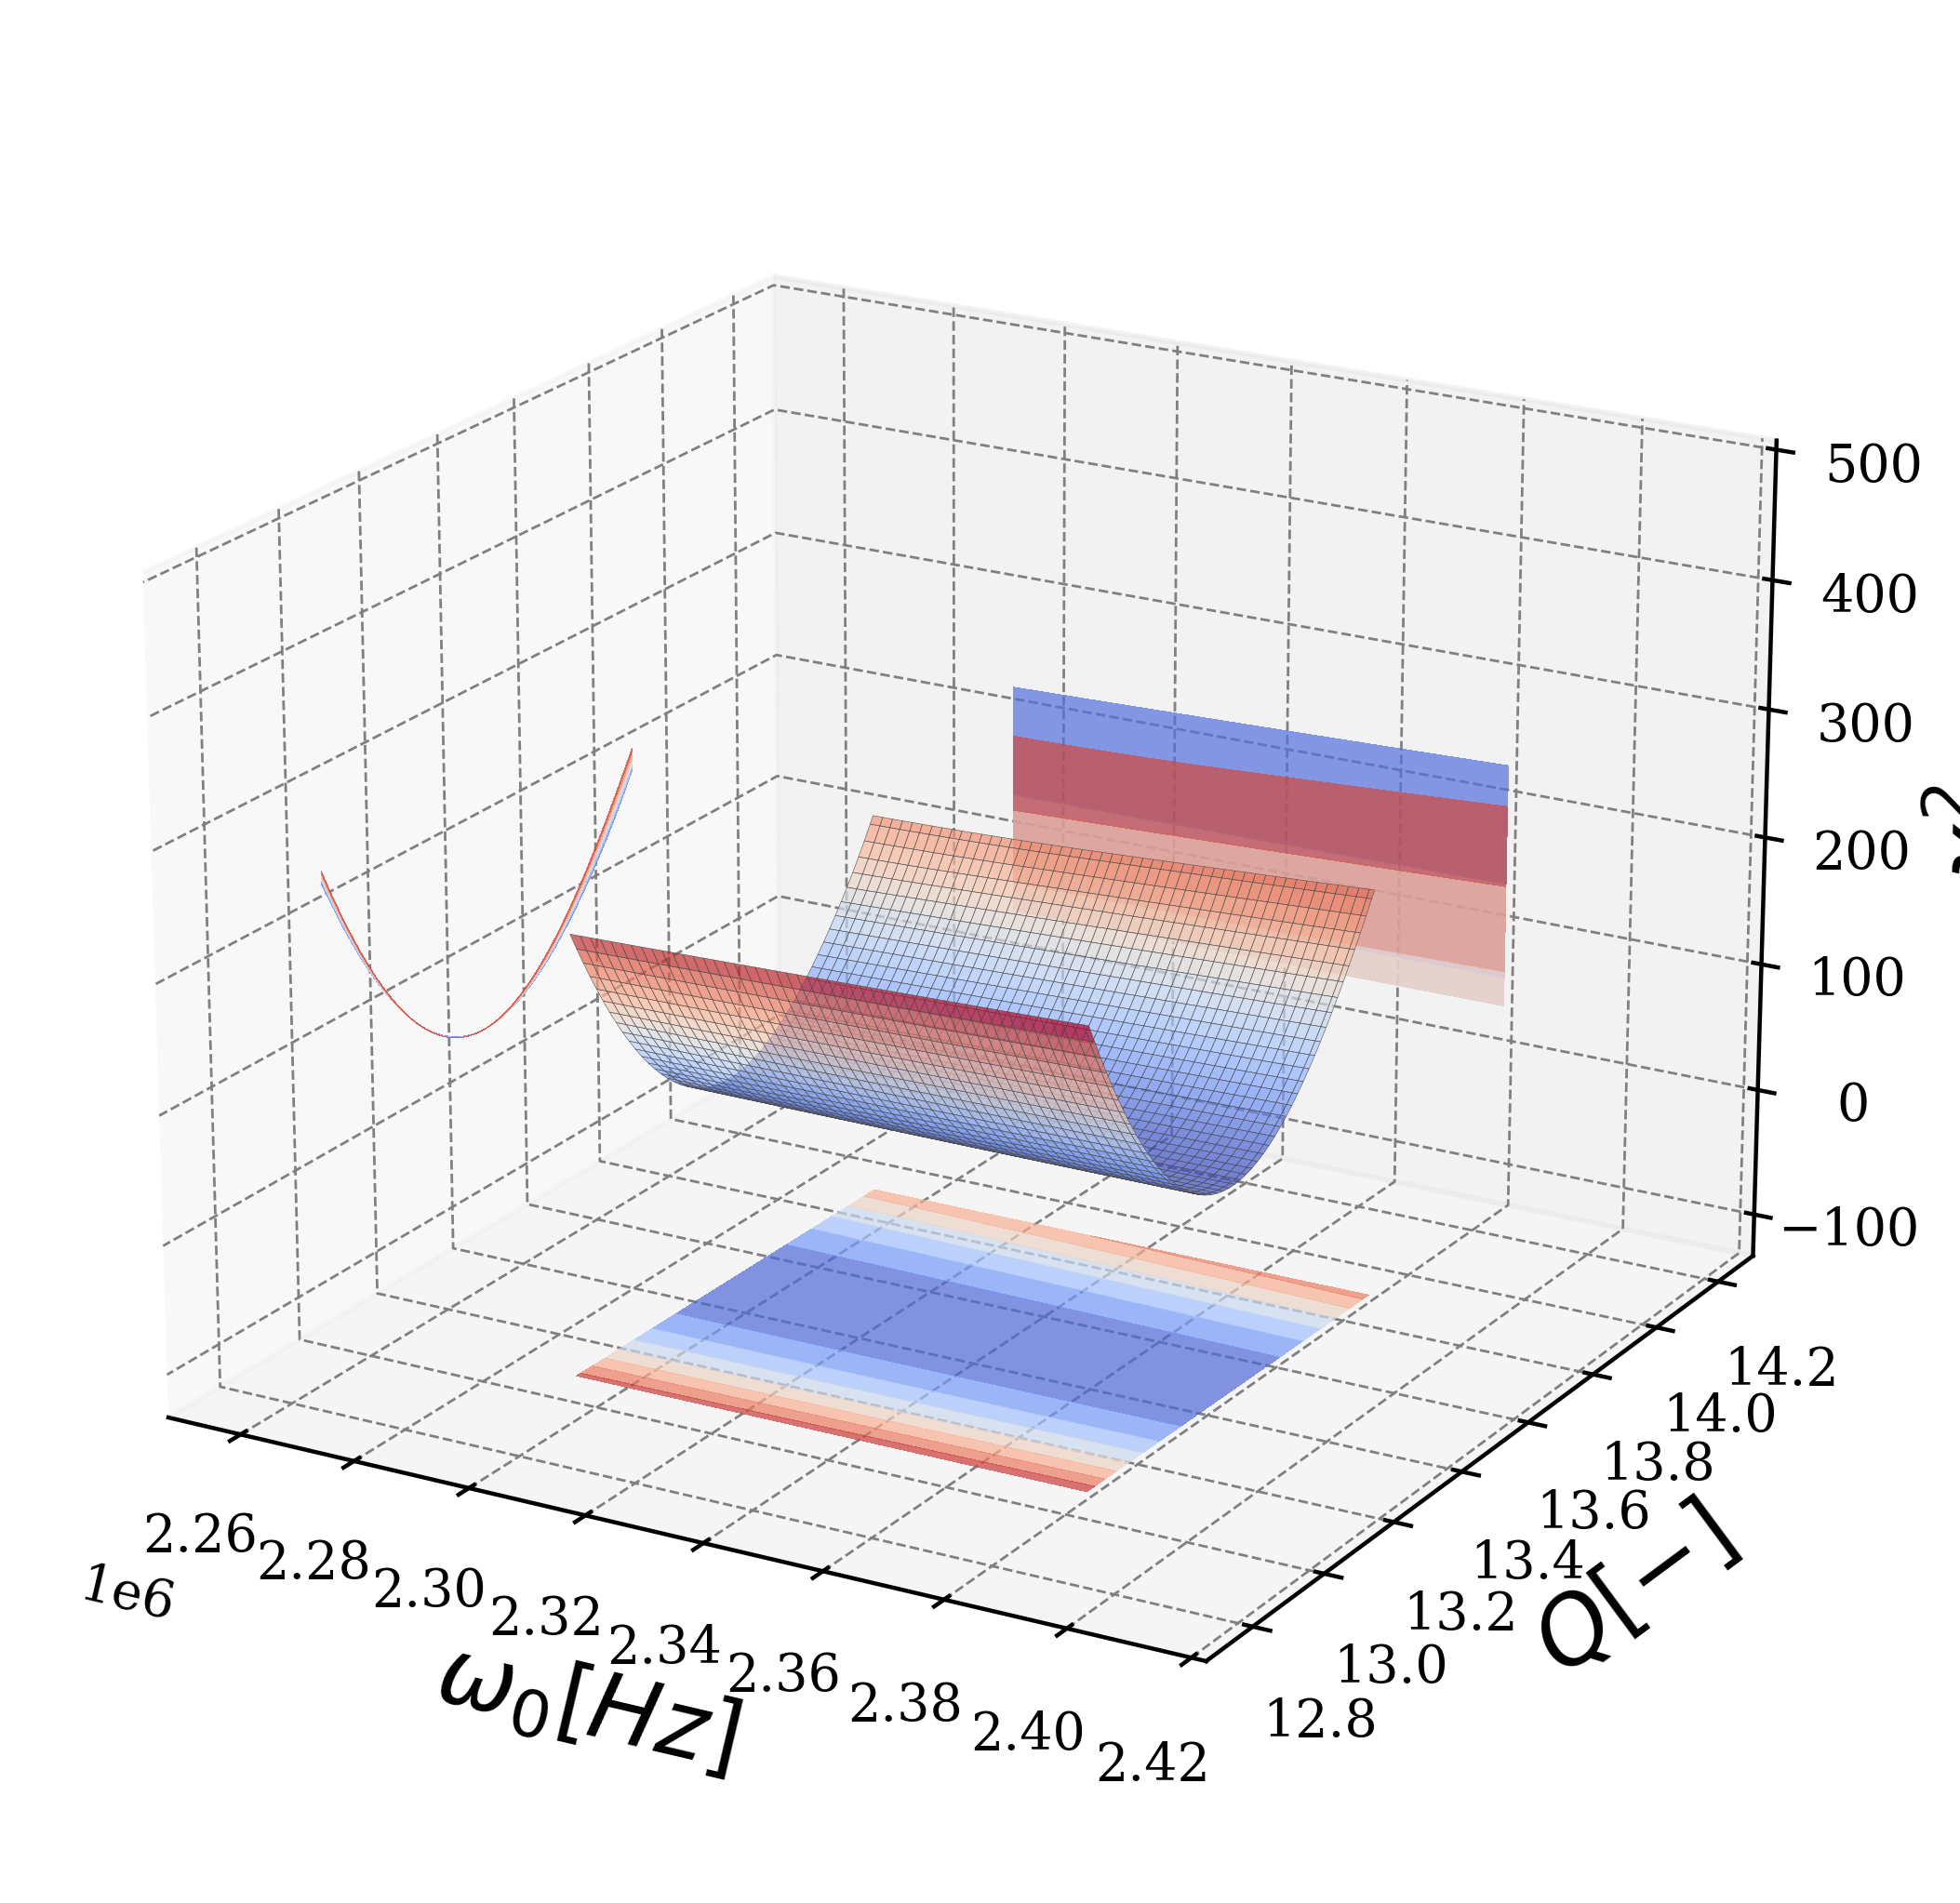

In [30]:
A,B = np.meshgrid(a_range, b_range)

# Creazione del grafico 3D
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(1,1,1, projection='3d')
ax.view_init(elev=20, azim=-60)
ax.set(xlim=xlim, ylim=ylim, zlim=zlim)

# Elementi del grafico
ax.plot_surface(A, B, ab_map, cmap='coolwarm', edgecolor='0.3', linewidth=0.1, alpha=0.7)
ax.contourf(A, B, ab_map, zdir='x', offset=xlim[0], cmap='coolwarm', alpha=0.7)
ax.contourf(A, B, ab_map, zdir='y', offset=ylim[1], cmap='coolwarm', alpha=0.7)
ax.contourf(A, B, ab_map, zdir='z', offset=zlim[0], cmap='coolwarm', alpha=0.7)
ax.plot(a_range, a_prof, zs=xlim[0], zdir='x', color='black', linewidth=1, linestyle="--")
ax.plot(b_range, b_prof, zs=ylim[1], zdir='y', color='black', linewidth=1, linestyle="--")

# Salvataggio del grafico
ax.set_xlabel("$" + xlabel + "[" + xunit + "]$")
ax.set_ylabel("$" + ylabel + "[" + yunit + "]$")
ax.set_zlabel("$\chi^2$")
let.salva_grafico(fig, grafico_output1)

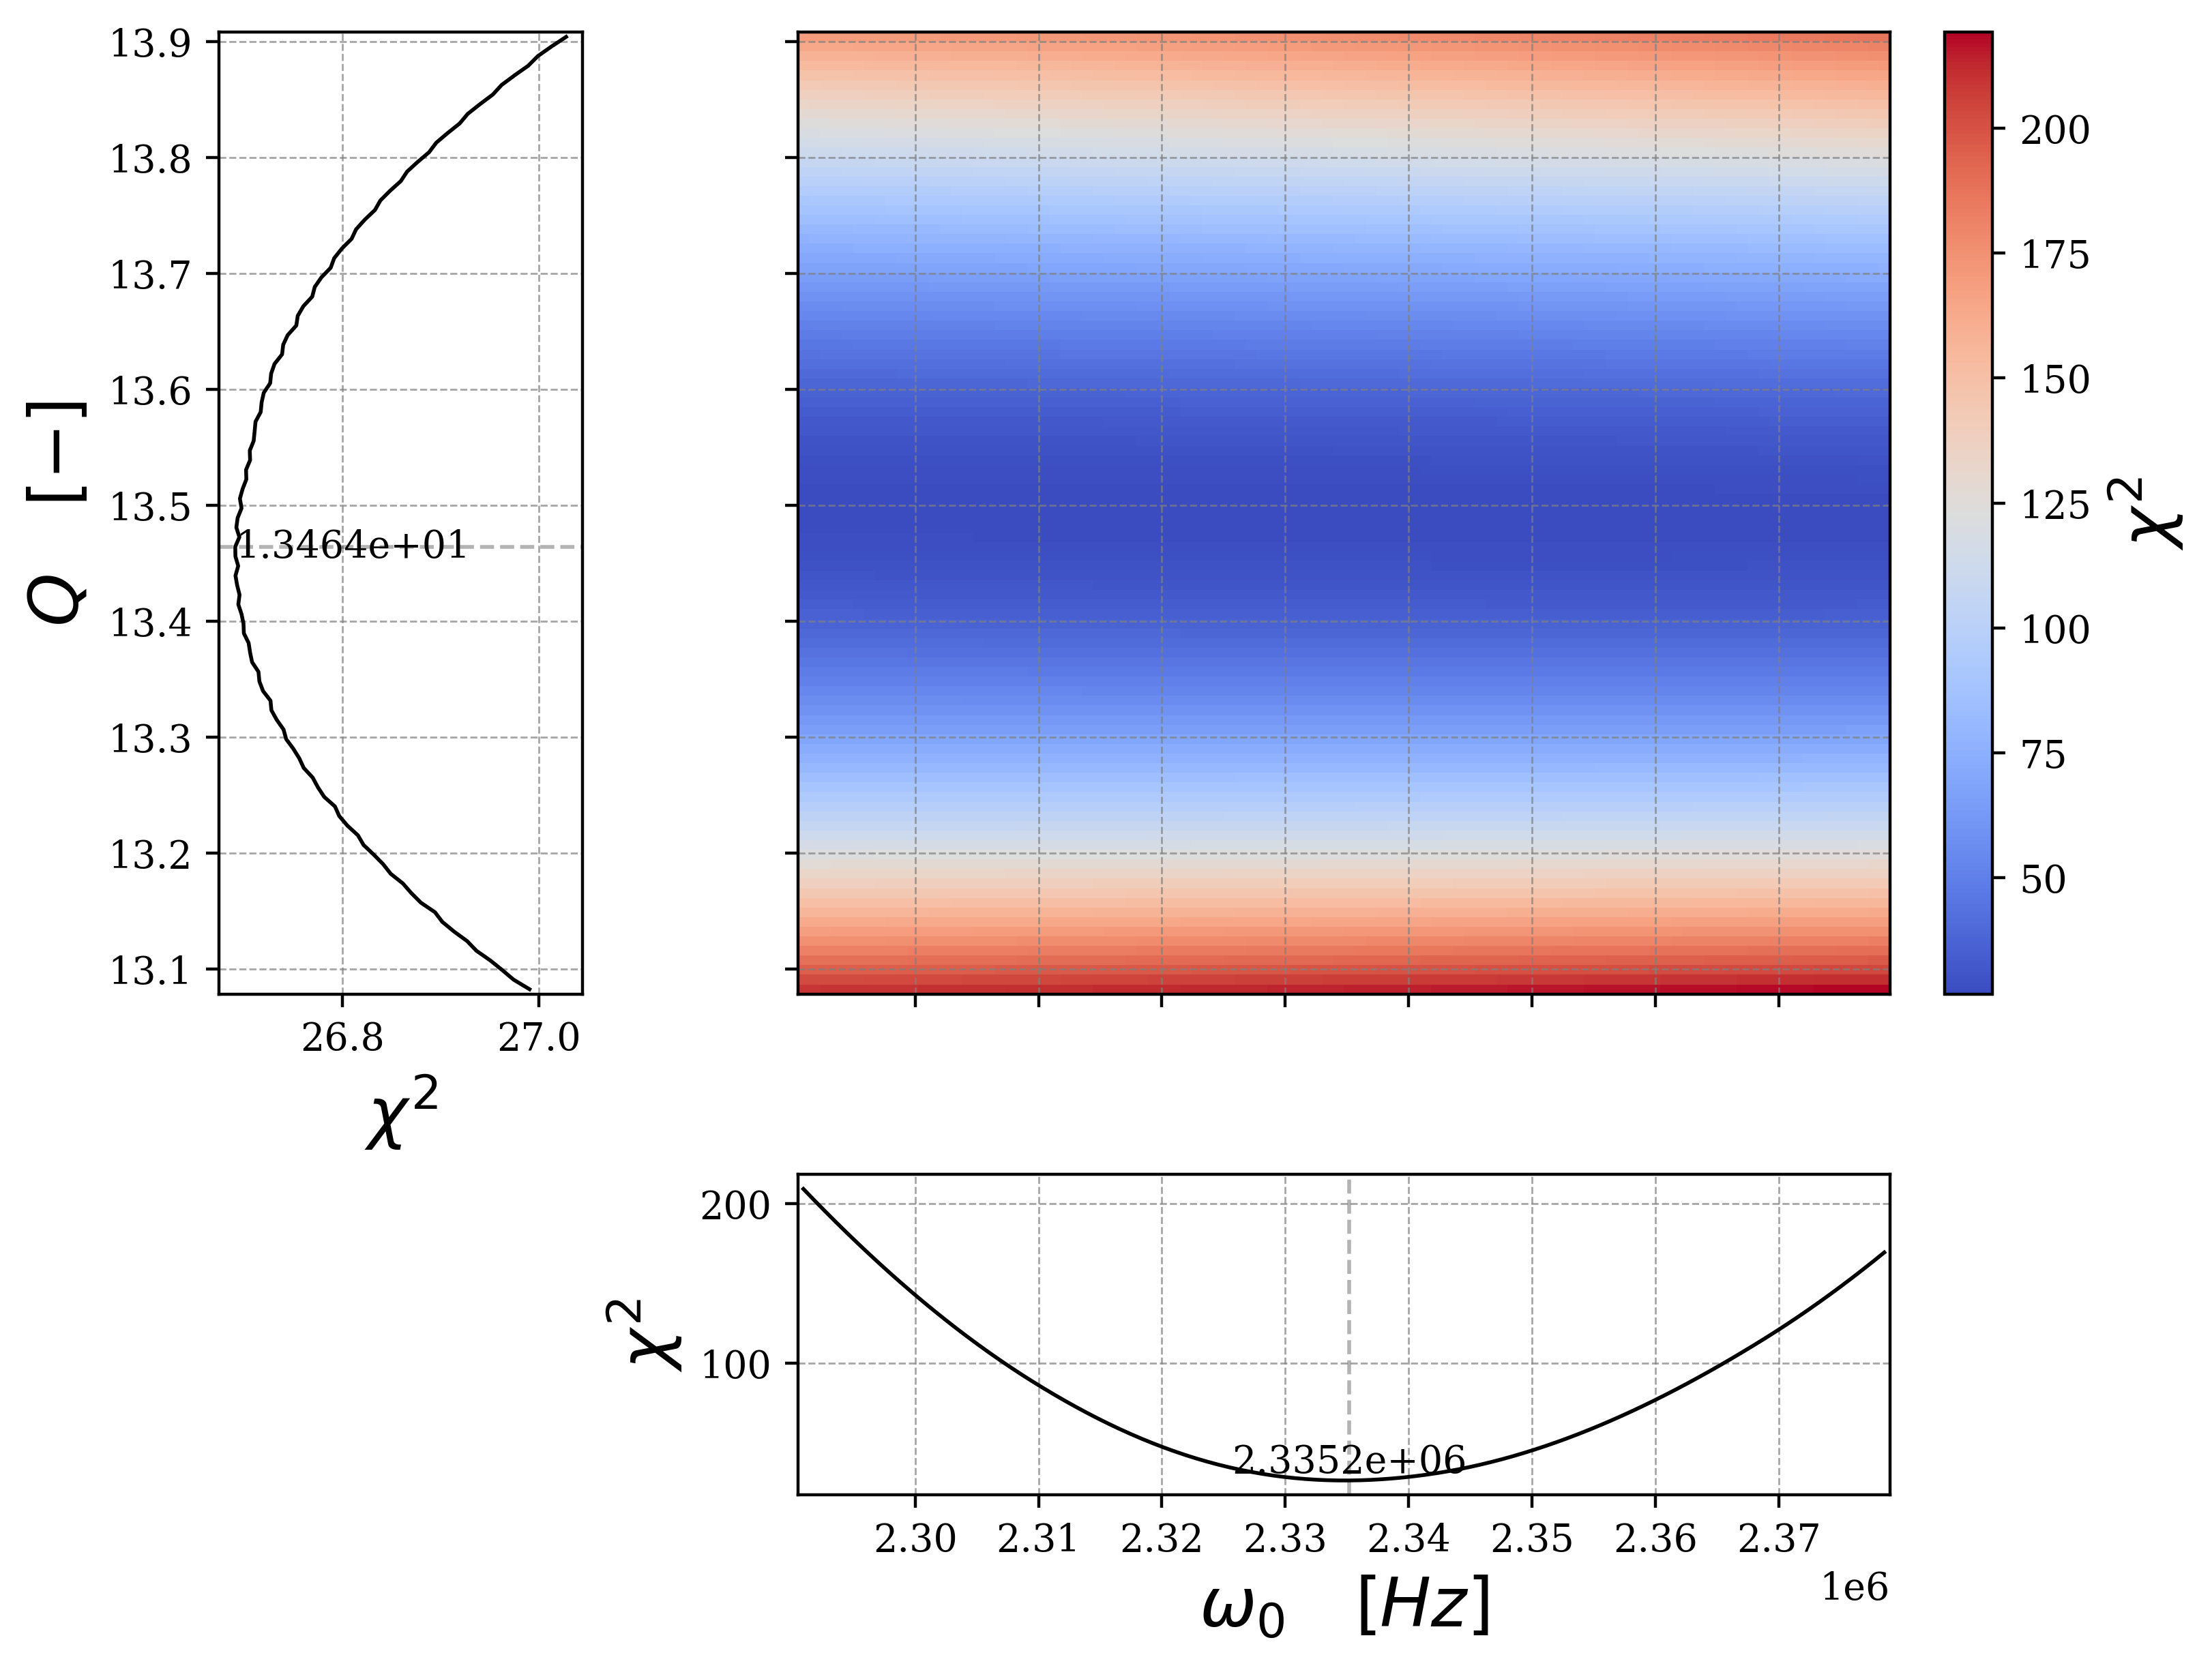

In [31]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6), constrained_layout=True)

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 3],
    figure=fig
)

ax_main = fig.add_subplot(gs[0, 1])  # 2D chi2 map
ax_b = fig.add_subplot(gs[0, 0], sharey=ax_main)   # sinistra (1D)
ax_blank = fig.add_subplot(gs[1, 0]) # vuoto
ax_a = fig.add_subplot(gs[1, 1], sharex=ax_main)     # sotto (1D)

ax_blank.axis('off')

# =========================
# 2D χ² MAP
# =========================
c = ax_main.pcolormesh(A, B, ab_map, shading='auto', cmap='coolwarm')
fig.colorbar(c, ax=ax_main, label=r"$\chi^2$")

ax_main.tick_params(axis='x', labelbottom=False)
ax_main.tick_params(axis='y', labelleft=False)

# =========================
# 1D projection B
# =========================
ax_b.plot(b_prof, b_range, color='black', lw=1)
ax_b.axhline(b_min, color='black', linestyle='--', linewidth=1, alpha=0.3) # Linea
ax_b.text(chi_min, b_min, f"{b_min:.4e}", fontsize=10, ha='left', va='center') # Testo
ax_b.set_xlabel(r"$\chi^2$")
ax_b.set_ylabel("$" + ylabel + "\quad[" + yunit + "]$")

# =========================
# 1D projection A
# =========================
ax_a.plot(a_range, a_prof, color='black', lw=1)
ax_a.axvline(a_min, color='black', linestyle='--', linewidth=1, alpha=0.3) # Linea
ax_a.text(a_min, chi_min, f"{a_min:.4e}", fontsize=10, ha='center', va='bottom') # Testo
ax_a.set_xlabel("$" + xlabel + "\quad[" + xunit + "]$")
ax_a.set_ylabel(r"$\chi^2$")

let.salva_grafico(fig, grafico_output2)